In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/BreakHis_small"

In [ ]:
!ls /content/drive/MyDrive/BreakHis_small

benign	malignant


In [ ]:
!pip install pennylane pennylane-lightning pennylane-qiskit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 

In [ ]:
!pip install torchvision torch torchaudio


In [ ]:
import os, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml


In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_ROOT = "/content/drive/MyDrive/BreakHis_small"

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2

EFFNET_EPOCHS = 25
HYBRID_EPOCHS = 30
LEARNING_RATE = 3e-4

N_QUBITS = 4
N_Q_LAYERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [ ]:
dataset_full = datasets.ImageFolder(DATA_ROOT, transform=transform)
classes = dataset_full.classes

targets = np.array([s[1] for s in dataset_full.samples])
idx = np.arange(len(targets))

train_idx, test_idx = train_test_split(
    idx, test_size=0.2, stratify=targets, random_state=SEED)

val_idx, test_idx = train_test_split(
    test_idx, test_size=0.5, stratify=targets[test_idx], random_state=SEED)

train_dataset = Subset(dataset_full, train_idx)
val_dataset = Subset(dataset_full, val_idx)
test_dataset = Subset(dataset_full, test_idx)

print("Classes:", dataset_full.classes)
print("Total images:", len(dataset_full))


Classes: ['benign', 'malignant']
Total images: 2000


In [ ]:
train_labels = targets[train_idx]
class_counts = np.bincount(train_labels)

class_weights = {i: 1.0 / c for i, c in enumerate(class_counts)}
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
from sklearn.metrics import accuracy_score
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = 100 * correct / total

    return avg_loss, acc


def evaluate(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            outputs = model(x)
            preds = outputs.argmax(dim=1).cpu().numpy()

            y_true.extend(y.numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred) * 100

    return acc, y_true, y_pred


In [ ]:
def train_with_history(model, train_loader, val_loader, optimizer, criterion, device, epochs, tag="Model"):
    train_acc_hist = []
    val_acc_hist = []
    train_loss_hist = []
    val_loss_hist = []

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_acc, _, _ = evaluate(model, val_loader, device)
        #scheduler.step(val_acc)

        # compute val loss
        model.eval()
        vloss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                vloss += loss.item() * x.size(0)

        val_loss = vloss / len(val_loader.dataset)

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)

        print(f"[{tag}] Epoch {epoch+1}: Train Acc={train_acc:.2f}% Val Acc={val_acc:.2f}%")

    return train_acc_hist, val_acc_hist, train_loss_hist, val_loss_hist


In [ ]:
import time

def train_with_time(model, train_loader, val_loader, optimizer, criterion, device, epochs, tag="Model"):
    start_total = time.time()

    train_acc_hist = []
    val_acc_hist = []
    epoch_times = []

    for epoch in range(epochs):

        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_acc, _, _ = evaluate(model, val_loader, device)

        t1 = time.time()
        epoch_time = t1 - t0
        epoch_times.append(epoch_time)

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)

        print(f"[{tag}] Epoch {epoch+1} | Acc={train_acc:.2f}% | Val={val_acc:.2f}% | Time={epoch_time:.2f}s")

    total_time = time.time() - start_total

    print(f"\n[{tag}] TOTAL TRAIN TIME: {total_time:.2f} sec")
    print(f"[{tag}] AVG EPOCH TIME: {sum(epoch_times)/len(epoch_times):.2f} sec")

    return train_acc_hist, val_acc_hist, epoch_times, total_time


In [ ]:
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


class QNNAux(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            0.01 * torch.randn(N_Q_LAYERS, N_QUBITS, dtype=torch.float32)
        )

    def forward(self, x):
        outputs = []
        for sample in x:
            sample = torch.tanh(sample) * np.pi
            q_out = qnode(sample, self.weights)   # q_out is a list

            # ✅ Proper conversion: list → torch tensor (float32)
            q_out = torch.stack(q_out).float()

            outputs.append(q_out)

        return torch.stack(outputs)



In [ ]:
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_v2_s(pretrained=True)

        self.backbone.classifier[1] = nn.Linear(
            self.backbone.classifier[1].in_features,
            num_classes
        )

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)   # 1→3 channel
        return self.backbone(x)


In [ ]:
class HybridEfficientNetQNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        eff = models.efficientnet_v2_s(pretrained=True)
        self.features = eff.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.feature_dim = 1280

        self.projector = nn.Sequential(
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, N_QUBITS)
        )

        self.qnn = QNNAux()

        self.summary = nn.Sequential(
            nn.Linear(self.feature_dim, 32),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(N_QUBITS + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)
        feat = self.pool(self.features(x)).flatten(1)

        q_in = self.projector(feat)
        q_out = self.qnn(q_in)

        summary = self.summary(feat)
        combined = torch.cat([q_out, summary], dim=1)

        return self.classifier(combined)


In [ ]:
#baseline = EfficientNetClassifier(len(classes)).to(DEVICE)
#criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

#for epoch in range(EFFNET_EPOCHS):
 #   loss, acc = train_one_epoch(baseline, train_loader, optimizer, criterion, DEVICE)
  #  val_acc, _, _ = evaluate(baseline, val_loader, DEVICE)
   # print(f"[EffNet] Epoch {epoch+1}: Train Acc={acc:.2f}% Val Acc={val_acc:.2f}%")
baseline = EfficientNetClassifier(len(classes)).to(DEVICE)
for p in baseline.backbone.features.parameters():
    p.requires_grad = False

#optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)
optimizer = optim.Adam(
    baseline.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

criterion = nn.CrossEntropyLoss()

eff_train_acc, eff_val_acc, eff_epoch_times1, eff_time1 = train_with_time(
    baseline,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    DEVICE,
    5,
    tag="EffNet-Frozen"
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:01<00:00, 79.9MB/s]


[EffNet-Frozen] Epoch 1 | Acc=51.31% | Val=54.00% | Time=219.98s
[EffNet-Frozen] Epoch 2 | Acc=58.06% | Val=61.00% | Time=146.69s
[EffNet-Frozen] Epoch 3 | Acc=60.50% | Val=66.00% | Time=151.46s
[EffNet-Frozen] Epoch 4 | Acc=62.25% | Val=66.50% | Time=152.04s
[EffNet-Frozen] Epoch 5 | Acc=63.19% | Val=66.50% | Time=148.74s

[EffNet-Frozen] TOTAL TRAIN TIME: 818.93 sec
[EffNet-Frozen] AVG EPOCH TIME: 163.78 sec


In [ ]:
for p in baseline.backbone.features.parameters():
    p.requires_grad = True

optimizer = optim.Adam(
    baseline.parameters(),
    lr=LEARNING_RATE * 0.5,   # smaller LR for fine tuning
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

eff_train_acc2, eff_val_acc2, eff_epoch_times2, eff_time2  = train_with_time(
    baseline,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    DEVICE,
    20,
    tag="EffNet-Finetune"
)


[EffNet-Finetune] Epoch 1 | Acc=72.75% | Val=71.50% | Time=339.71s
[EffNet-Finetune] Epoch 2 | Acc=88.12% | Val=72.00% | Time=343.77s
[EffNet-Finetune] Epoch 3 | Acc=91.69% | Val=73.50% | Time=345.11s
[EffNet-Finetune] Epoch 4 | Acc=94.31% | Val=78.00% | Time=340.55s
[EffNet-Finetune] Epoch 5 | Acc=96.44% | Val=81.50% | Time=337.96s
[EffNet-Finetune] Epoch 6 | Acc=98.19% | Val=81.50% | Time=336.46s
[EffNet-Finetune] Epoch 7 | Acc=97.69% | Val=79.50% | Time=336.53s
[EffNet-Finetune] Epoch 8 | Acc=97.50% | Val=79.50% | Time=341.55s
[EffNet-Finetune] Epoch 9 | Acc=98.19% | Val=82.00% | Time=338.61s
[EffNet-Finetune] Epoch 10 | Acc=98.31% | Val=80.00% | Time=337.03s
[EffNet-Finetune] Epoch 11 | Acc=98.81% | Val=80.00% | Time=330.82s
[EffNet-Finetune] Epoch 12 | Acc=98.50% | Val=83.50% | Time=335.59s
[EffNet-Finetune] Epoch 13 | Acc=99.25% | Val=81.50% | Time=335.10s
[EffNet-Finetune] Epoch 14 | Acc=99.19% | Val=79.50% | Time=337.59s
[EffNet-Finetune] Epoch 15 | Acc=98.88% | Val=84.00% | Ti

In [ ]:
# merge phase1 + phase2 history
eff_train_acc += eff_train_acc2
eff_val_acc += eff_val_acc2


In [ ]:
torch.save(baseline.state_dict(), "efficientnetv2_baseline_best.pth")


In [ ]:
#hybrid = HybridEfficientNetQNN(len(classes))
#HYBRID_DEVICE = torch.device("cpu")

#criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(hybrid.parameters(), lr=LEARNING_RATE)

#for epoch in range(HYBRID_EPOCHS):
 #   loss, acc = train_one_epoch(hybrid, train_loader, optimizer, criterion, HYBRID_DEVICE)
  #  val_acc, _, _ = evaluate(hybrid, val_loader, HYBRID_DEVICE)
   # print(f"[Hybrid] Epoch {epoch+1}: Train Acc={acc:.2f}% Val Acc={val_acc:.2f}%")
HYBRID_DEVICE = torch.device("cpu")

hybrid = HybridEfficientNetQNN(len(classes))

for p in hybrid.features.parameters():
    p.requires_grad = False

optimizer = optim.Adam(
    hybrid.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

hyb_train_acc, hyb_val_acc, hyb_epoch_times1, hyb_time1 = train_with_time(
    hybrid,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    HYBRID_DEVICE,
    10,
    tag="Hybrid-Frozen"
)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[Hybrid-Frozen] Epoch 1 | Acc=55.38% | Val=58.00% | Time=167.51s
[Hybrid-Frozen] Epoch 2 | Acc=62.50% | Val=61.50% | Time=172.82s
[Hybrid-Frozen] Epoch 3 | Acc=63.12% | Val=69.00% | Time=173.26s
[Hybrid-Frozen] Epoch 4 | Acc=68.25% | Val=65.50% | Time=171.64s
[Hybrid-Frozen] Epoch 5 | Acc=65.44% | Val=65.50% | Time=169.54s
[Hybrid-Frozen] Epoch 6 | Acc=67.31% | Val=68.00% | Time=170.81s
[Hybrid-Frozen] Epoch 7 | Acc=69.31% | Val=68.00% | Time=179.12s
[Hybrid-Frozen] Epoch 8 | Acc=69.44% | Val=64.50% | Time=171.99s
[Hybrid-Frozen] Epoch 9 | Acc=71.69% | Val=65.50% | Time=171.82s
[Hybrid-Frozen] Epoch 10 | Acc=70.62% | Val=68.50% | Time=172.49s

[Hybrid-Frozen] TOTAL TRAIN TIME: 1721.00 sec
[Hybrid-Frozen] AVG EPOCH TIME: 172.10 sec


In [ ]:
for p in hybrid.features.parameters():
    p.requires_grad = True

optimizer = optim.Adam(
    hybrid.parameters(),
    lr=LEARNING_RATE * 0.5,
    weight_decay=1e-4
)

hyb_train_acc2, hyb_val_acc2, hyb_epoch_times2, hyb_time2 = train_with_time(
    hybrid,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    HYBRID_DEVICE,
    20,
    tag="Hybrid-Finetune"
)


[Hybrid-Finetune] Epoch 1 | Acc=73.94% | Val=76.00% | Time=379.17s
[Hybrid-Finetune] Epoch 2 | Acc=85.06% | Val=78.00% | Time=376.86s
[Hybrid-Finetune] Epoch 3 | Acc=91.12% | Val=77.50% | Time=369.36s
[Hybrid-Finetune] Epoch 4 | Acc=92.19% | Val=77.50% | Time=376.52s
[Hybrid-Finetune] Epoch 5 | Acc=94.50% | Val=77.50% | Time=370.95s
[Hybrid-Finetune] Epoch 6 | Acc=96.88% | Val=82.50% | Time=373.56s
[Hybrid-Finetune] Epoch 7 | Acc=96.50% | Val=82.50% | Time=368.34s
[Hybrid-Finetune] Epoch 8 | Acc=97.81% | Val=74.00% | Time=378.00s
[Hybrid-Finetune] Epoch 9 | Acc=97.62% | Val=80.50% | Time=378.48s
[Hybrid-Finetune] Epoch 10 | Acc=98.25% | Val=79.50% | Time=383.33s
[Hybrid-Finetune] Epoch 11 | Acc=98.31% | Val=80.50% | Time=376.88s
[Hybrid-Finetune] Epoch 12 | Acc=98.25% | Val=84.00% | Time=379.90s
[Hybrid-Finetune] Epoch 13 | Acc=98.25% | Val=83.00% | Time=382.54s
[Hybrid-Finetune] Epoch 14 | Acc=98.12% | Val=82.50% | Time=384.15s
[Hybrid-Finetune] Epoch 15 | Acc=98.69% | Val=81.50% | Ti

In [ ]:
# merge phase1 + phase2 history
hyb_train_acc += hyb_train_acc2
hyb_val_acc += hyb_val_acc2


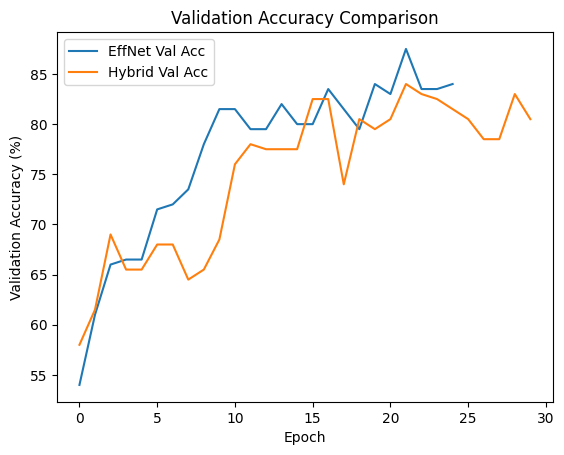

In [ ]:
#plotting accuracy graphs
import matplotlib.pyplot as plt

plt.figure()
plt.plot(eff_val_acc, label="EffNet Val Acc")
plt.plot(hyb_val_acc, label="Hybrid Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()


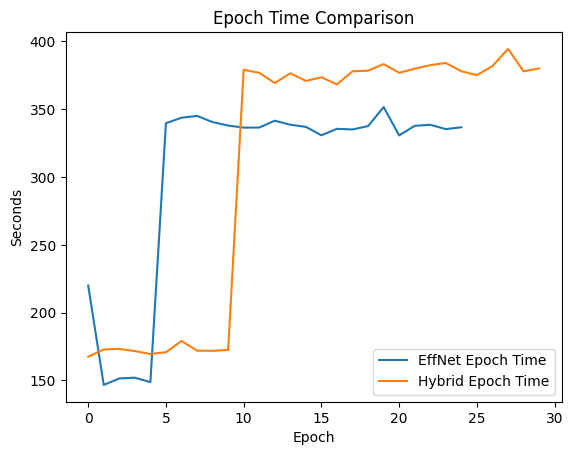

In [ ]:
#plotting Epoch Time Plot
plt.figure()
plt.plot(eff_epoch_times1 + eff_epoch_times2, label="EffNet Epoch Time")
plt.plot(hyb_epoch_times1 + hyb_epoch_times2, label="Hybrid Epoch Time")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Epoch Time Comparison")
plt.legend()
plt.show()



In [ ]:
#Final Test Evaluation (both models)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def test_metrics(model, loader, device, name):
    acc, y_true, y_pred = evaluate(model, loader, device)

    print(f"\n{name} Test Accuracy: {acc:.2f}%")
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



EfficientNetV2 Test Accuracy: 77.50%
              precision    recall  f1-score   support

      benign       0.78      0.77      0.77       100
   malignant       0.77      0.78      0.78       100

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.78      0.77       200



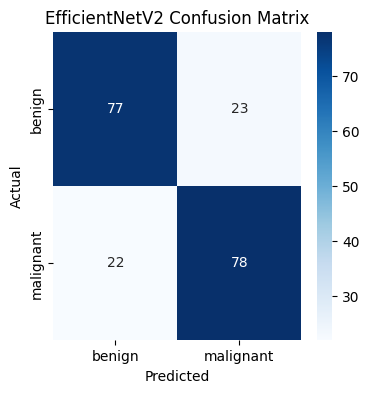


Hybrid QNN Test Accuracy: 72.50%
              precision    recall  f1-score   support

      benign       0.69      0.83      0.75       100
   malignant       0.78      0.62      0.69       100

    accuracy                           0.72       200
   macro avg       0.74      0.72      0.72       200
weighted avg       0.74      0.72      0.72       200



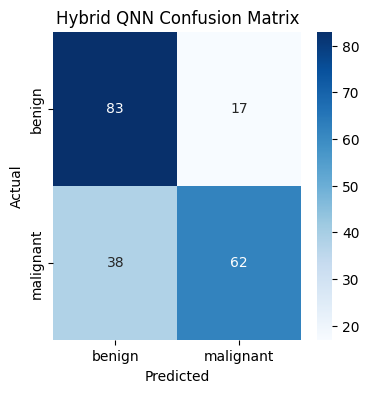

In [ ]:
#run both the models
test_metrics(baseline, test_loader, DEVICE, "EfficientNetV2")
test_metrics(hybrid, test_loader, HYBRID_DEVICE, "Hybrid QNN")


In [ ]:
print("\n===== TRAINING TIME SUMMARY =====")
print("EffNet total:", eff_time1 + eff_time2, "sec")
print("Hybrid total:", hyb_time1 + hyb_time2, "sec")



===== TRAINING TIME SUMMARY =====
EffNet total: 7586.117823600769 sec
Hybrid total: 9286.758797168732 sec


In [ ]:
def measure_inference_time(model, loader, device, name):
    model.eval()
    batch_times = []

    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i == 30:   # measure first 30 batches only
                break
            x = x.to(device)

            t0 = time.time()
            _ = model(x)
            t1 = time.time()

            batch_times.append(t1 - t0)

    avg_batch = sum(batch_times) / len(batch_times)
    per_image = avg_batch / loader.batch_size

    print(f"\n{name} Inference:")
    print(f"Avg batch time: {avg_batch:.4f} sec")
    print(f"Per image time: {per_image:.6f} sec")

    return avg_batch, per_image


In [ ]:
measure_inference_time(baseline, test_loader, DEVICE, "EfficientNetV2-S")
measure_inference_time(hybrid, test_loader, HYBRID_DEVICE, "Hybrid QNN")



EfficientNetV2-S Inference:
Avg batch time: 1.4616 sec
Per image time: 0.045675 sec

Hybrid QNN Inference:
Avg batch time: 1.7408 sec
Per image time: 0.054399 sec


(1.7407686710357666, 0.054399020969867706)

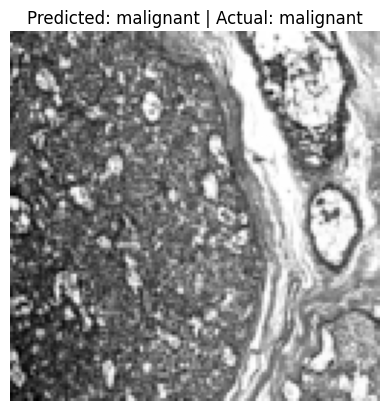

In [ ]:
import matplotlib.pyplot as plt
import torch

def show_prediction(model, loader, device, classes):
    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            # take the first image from batch
            img = images[0].cpu()
            pred_label = classes[preds[0].item()]
            true_label = classes[labels[0].item()]

            # convert tensor image for display
            img = img.squeeze().numpy()

            plt.imshow(img, cmap='gray')
            plt.title(f"Predicted: {pred_label} | Actual: {true_label}")
            plt.axis('off')
            plt.show()

            break

# run it
show_prediction(baseline, test_loader, DEVICE, classes)

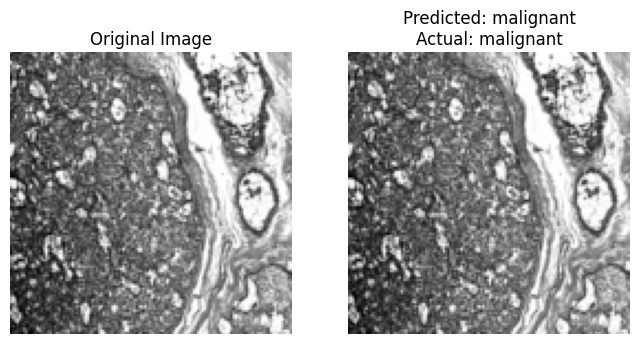

In [ ]:
import matplotlib.pyplot as plt
import torch

def show_original_and_prediction(model, loader, device, classes):
    model.eval()

    with torch.no_grad():
        for images, labels in loader:

            inputs = images.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            # take first image
            img = images[0].cpu().squeeze().numpy()
            pred_label = classes[preds[0].item()]
            true_label = classes[labels[0].item()]

            plt.figure(figsize=(8,4))

            # Original Image
            plt.subplot(1,2,1)
            plt.imshow(img, cmap='gray')
            plt.title("Original Image")
            plt.axis("off")

            # Prediction
            plt.subplot(1,2,2)
            plt.imshow(img, cmap='gray')
            plt.title(f"Predicted: {pred_label}\nActual: {true_label}")
            plt.axis("off")

            plt.show()

            break


# Run
show_original_and_prediction(baseline, test_loader, DEVICE, classes)

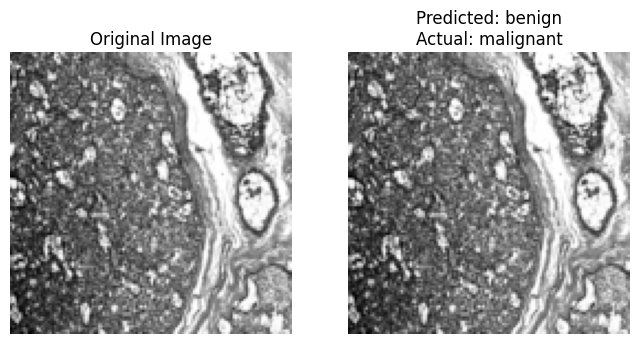

In [ ]:
import matplotlib.pyplot as plt
import torch

def show_original_and_prediction(model, loader, device, classes):
    model.eval()

    with torch.no_grad():
        for images, labels in loader:

            inputs = images.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            # take first image
            img = images[0].cpu().squeeze().numpy()
            pred_label = classes[preds[0].item()]
            true_label = classes[labels[0].item()]

            plt.figure(figsize=(8,4))

            # Original Image
            plt.subplot(1,2,1)
            plt.imshow(img, cmap='gray')
            plt.title("Original Image")
            plt.axis("off")

            # Prediction
            plt.subplot(1,2,2)
            plt.imshow(img, cmap='gray')
            plt.title(f"Predicted: {pred_label}\nActual: {true_label}")
            plt.axis("off")

            plt.show()

            break


# Run
show_original_and_prediction(hybrid, test_loader, DEVICE, classes)

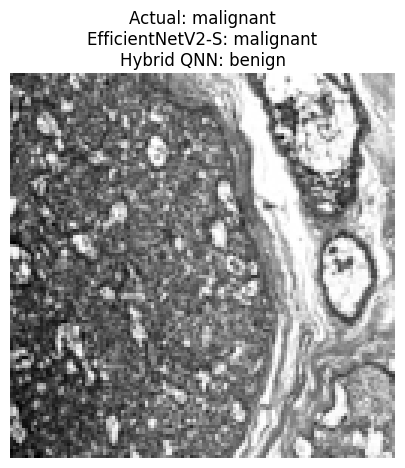

In [ ]:
import matplotlib.pyplot as plt
import torch

def compare_models(baseline_model, hybrid_model, loader, device1, device2, classes):

    baseline_model.eval()
    hybrid_model.eval()

    with torch.no_grad():
        for images, labels in loader:

            img = images[0].unsqueeze(0)

            # EfficientNet prediction
            out1 = baseline_model(img.to(device1))
            pred1 = classes[out1.argmax(dim=1).item()]

            # Hybrid prediction
            out2 = hybrid_model(img.to(device2))
            pred2 = classes[out2.argmax(dim=1).item()]

            actual = classes[labels[0].item()]

            # image for display
            display_img = images[0].cpu().squeeze().numpy()

            plt.figure(figsize=(6,5))
            plt.imshow(display_img, cmap='gray')
            plt.axis("off")

            plt.title(
                f"Actual: {actual}\n"
                f"EfficientNetV2-S: {pred1}\n"
                f"Hybrid QNN: {pred2}"
            )

            plt.show()

            break


# Run comparison
compare_models(baseline, hybrid, test_loader, DEVICE, HYBRID_DEVICE, classes)

In [ ]:
import os
import matplotlib.pyplot as plt
import torch

def save_prediction_examples(baseline_model, hybrid_model, loader, device1, device2, classes, num_images=6):

    baseline_model.eval()
    hybrid_model.eval()

    save_dir = "prediction_examples"
    os.makedirs(save_dir, exist_ok=True)

    count = 0

    with torch.no_grad():
        for images, labels in loader:

            for i in range(images.size(0)):

                img = images[i].unsqueeze(0)

                # EfficientNet prediction
                out1 = baseline_model(img.to(device1))
                pred1 = classes[out1.argmax(dim=1).item()]

                # Hybrid prediction
                out2 = hybrid_model(img.to(device2))
                pred2 = classes[out2.argmax(dim=1).item()]

                actual = classes[labels[i].item()]

                display_img = images[i].cpu().squeeze().numpy()

                plt.figure(figsize=(5,4))
                plt.imshow(display_img, cmap='gray')
                plt.axis("off")

                plt.title(
                    f"Actual: {actual}\n"
                    f"EfficientNetV2-S: {pred1}\n"
                    f"Hybrid QNN: {pred2}"
                )

                filename = f"{save_dir}/prediction_{count+1}.png"
                plt.savefig(filename, bbox_inches='tight')
                plt.close()

                count += 1

                if count >= num_images:
                    print(f"{num_images} prediction images saved in '{save_dir}' folder")
                    return

In [ ]:
save_prediction_examples(
    baseline,
    hybrid,
    test_loader,
    DEVICE,
    HYBRID_DEVICE,
    classes,
    num_images=6
)

6 prediction images saved in 'prediction_examples' folder
